### 1.数据的加载

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
offline = pd.read_csv('ccf_offline_stage1_train.csv',parse_dates=['Date_received','Date'])
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754884 entries, 0 to 1754883
Data columns (total 7 columns):
 #   Column         Dtype         
---  ------         -----         
 0   User_id        int64         
 1   Merchant_id    int64         
 2   Coupon_id      float64       
 3   Discount_rate  object        
 4   Distance       float64       
 5   Date_received  datetime64[ns]
 6   Date           datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(2), object(1)
memory usage: 93.7+ MB


### 2.数据的规整

In [3]:
# 计算每一列的空值
offline.isnull().sum()

User_id               0
Merchant_id           0
Coupon_id        701602
Discount_rate    701602
Distance         106003
Date_received    701602
Date             977900
dtype: int64

#### 2.1转换满减为折扣率

In [4]:
def discount_rate_opt(s) :
    if pd.isna(s):
        return np.NaN
    s_str = str(s)
    if ':' in s:
        split = s.split(':')
        discount_rate = (int(split[0])-int(split[1]))/int(split[0])
        return round(discount_rate,2)
    else:
        return float(s)
offline['Discount_rate'] = offline['Discount_rate'].map(discount_rate_opt)
offline['Discount_rate'].head()

0     NaN
1    0.87
2    0.95
3    0.95
4    0.95
Name: Discount_rate, dtype: float64

In [5]:
# 折扣券id为0，折扣率和折扣日期无意义
np.all([True,False,True])

nan1 = offline['Coupon_id'].isnull()
nan2 = offline['Date_received'].isnull()
np.all(nan1 == nan2)

True

In [6]:
nan3 = offline['Discount_rate'].isnull()
np.all(nan1 == nan3)

True

#### 2.2是否使用消费券占比

In [7]:
# 如果Date = null & Coupon_id != null，有券未消费（cpon_no_consume）
# 如果Date = null & Coupon_id = null，无券未消费（no_cpon_no_consume）
# 如果Date != null & Coupon_id = null，无券消费（no_cpon_consume）
# 如果Date != null & Coupon_id != null，有券消费（cpon_consume）
cpon_no_consume = offline[(offline['Date'].isnull() & offline['Coupon_id'].notnull())]
no_cpon_no_consume = offline[(offline['Date'].isnull() & offline['Coupon_id'].isnull())]
no_cpon_consume = offline[(offline['Date'].notnull() & offline['Coupon_id'].isnull())]
cpon_consume = offline[(offline['Date'].notnull() & offline['Coupon_id'].notnull())]
print('有券未消费{}'.format(len(cpon_no_consume)))
print('无券未消费{}'.format(len(no_cpon_no_consume)))  # 无意义，不做分析
print('无券消费{}'.format(len(no_cpon_consume)))
print('有券消费{}'.format(len(cpon_consume)))

有券未消费977900
无券未消费0
无券消费701602
有券消费75382


### 3.数据分析

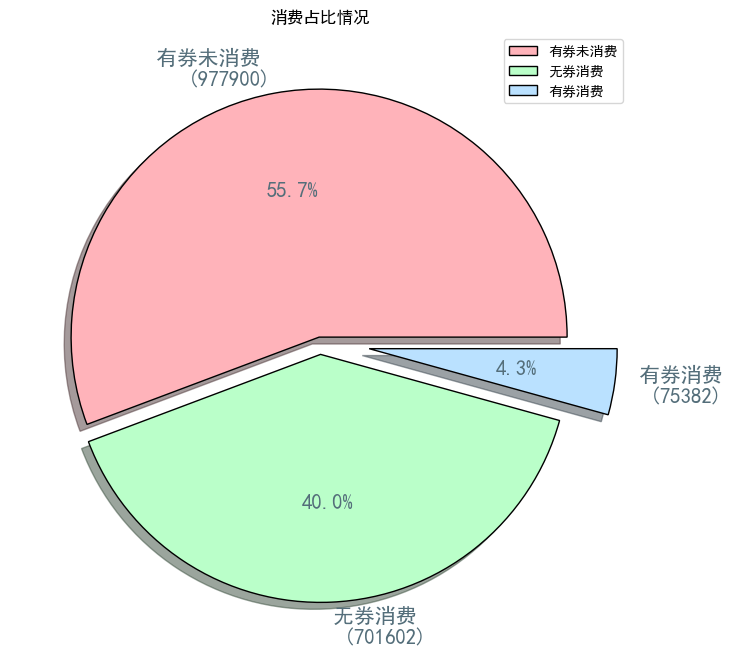

In [8]:
# 消费方式构成的饼图
consume_status_dict = {'cpon_no_consume':len(cpon_no_consume),'no_cpon_consume':len(no_cpon_consume),'cpon_consume':len(cpon_consume)}
consume_status = pd.Series(consume_status_dict)

fig,ax=plt.subplots(1,1,figsize=(8,10))
consume_status.plot.pie(ax=ax,
                        autopct='%.1f%%',
                        shadow=True,
                        explode=[0.02,0.05,0.2],
                        textprops={'fontsize':15,'color':'#546E7A'},
                        wedgeprops={'linewidth':1,'edgecolor':'black'},
                        colors=['#FFB3BA','#BAFFC9','#BAE1FF'],
                        labels=['有券未消费 \n ({})'.format(len(cpon_no_consume)),
                                '无券消费 \n ({})'.format(len(no_cpon_consume)),
                                '有券消费 \n ({})'.format(len(cpon_consume))]
                       )
ax.set_ylabel('')
ax.set_title('消费占比情况')
plt.legend(labels=['有券未消费','无券消费','有券消费'])
# 由图可知：有券未消费占比最大，有55.7%
# 无券消费占比40%，可能是新用户无券也可能是对老用户吸引力不大
# 用券消费占比4.3%，说明优惠券使用率不高，可以考虑加大优惠力度

#### 3.1在有券消费人群中，距离和折扣力度的影响

In [9]:
# 各商家对应的顾客到店的平均距离
Merchant_distance = cpon_consume.groupby('Merchant_id')['Distance'].mean()
Merchant_distance[Merchant_distance==0]
# 4076个商家中1431家的有券消费用户平均范围在500m内

Merchant_id
3       0.0
4       0.0
13      0.0
14      0.0
18      0.0
       ... 
8806    0.0
8824    0.0
8828    0.0
8849    0.0
8856    0.0
Name: Distance, Length: 1431, dtype: float64

0.8847410562670716

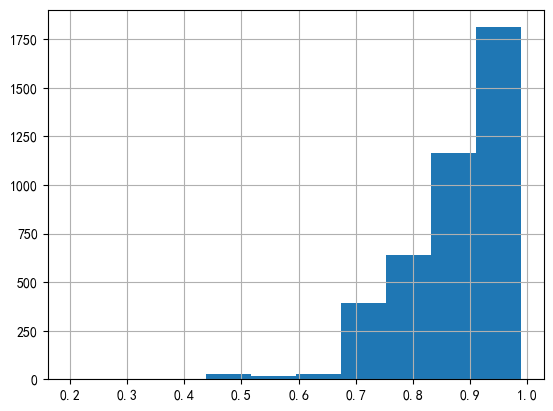

In [10]:
# 各商家对应的顾客到店消费平均折扣力度
Merchant_discount_rate = cpon_consume.groupby('Merchant_id')['Discount_rate'].mean()
Merchant_discount_rate.hist()
Merchant_discount_rate.mean()  # 88折

#### 3.2持券到店消费人数最多的商家

In [11]:
popular_merchant = cpon_consume.groupby('Merchant_id')['User_id'].apply(lambda x:len(x.unique())).sort_values(ascending=False)
popular_merchant_500 = popular_merchant[popular_merchant>500]
popular_merchant_500.name = 'customer_count'  # 指定列名
print(len(popular_merchant_500))
print(popular_merchant_500)
# 可以适当借鉴学习这批商家的推广方式

16
Merchant_id
5341    2800
760     2627
3381    2248
6485    2029
2099    1401
2934    1310
450     1094
3532     968
7555     925
1520     870
6901     855
3621     851
4142     832
1379     587
1469     584
1433     559
Name: customer_count, dtype: int64


#### 3.3持券消费500人以上的商家连接平均距离和平均折扣

In [12]:
merchant_pop_dis = pd.merge(left=popular_merchant_500,right=Merchant_distance,on='Merchant_id',how='inner')
merchant_pop_dis_rate = pd.merge(left=merchant_pop_dis,right=Merchant_discount_rate,on='Merchant_id',how='inner')
merchant_pop_dis_rate

,customer_count,Distance,Discount_rate
Merchant_id,,,
5341,2800,0.168598,0.826036
760,2627,0.349866,0.799873
3381,2248,1.652429,0.744150
6485,2029,0.368567,0.770439
2099,1401,0.968072,0.900000
2934,1310,1.114833,0.830000
450,1094,0.892164,0.819274
3532,968,0.272498,0.852289
7555,925,1.329977,0.828381


#### 3.4到店消费人数与平均距离和折扣力度的相关系数

In [13]:
merchant_pop_dis_rate.corr()
# 均呈现负相关，属于正常现象

,customer_count,Distance,Discount_rate
customer_count,1.000000,-0.306180,-0.204102
Distance,-0.306180,1.000000,-0.397376
Discount_rate,-0.204102,-0.397376,1.000000


<Axes: >

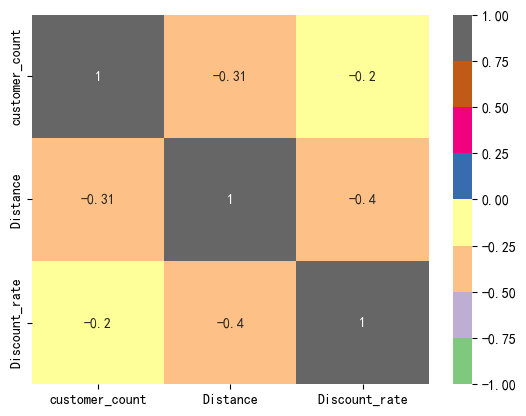

In [14]:
# 用热力图展示相关系数
sns.heatmap(data=merchant_pop_dis_rate.corr(),annot=True,cmap='Accent',vmax=1,vmin=-1)
# 1.到店消费人数的多少与顾客到店铺之间的距离呈现负相关，相关系数0.31，在0.3~0.5之间，为低度相关
# 2.到店消费人数的多少与优惠打折力度呈现负相关，相关系数0.2，在0~0.3之间，为相关程度极弱
# 3.综上所述，这批店家火爆的原因应该与自身有关，与距离和折扣相关不大

#### 3.5发券量与用券量的使用情况分析

In [35]:
# 消费日期
date_sort = offline[offline['Date'].notnull()]['Date'].sort_values().unique()
date_sort

<DatetimeArray>
['2016-01-01 00:00:00', '2016-01-02 00:00:00', '2016-01-03 00:00:00',
 '2016-01-04 00:00:00', '2016-01-05 00:00:00', '2016-01-06 00:00:00',
 '2016-01-07 00:00:00', '2016-01-08 00:00:00', '2016-01-09 00:00:00',
 '2016-01-10 00:00:00',
 ...
 '2016-06-21 00:00:00', '2016-06-22 00:00:00', '2016-06-23 00:00:00',
 '2016-06-24 00:00:00', '2016-06-25 00:00:00', '2016-06-26 00:00:00',
 '2016-06-27 00:00:00', '2016-06-28 00:00:00', '2016-06-29 00:00:00',
 '2016-06-30 00:00:00']
Length: 182, dtype: datetime64[ns]

In [37]:
# 领券日期
date_received_sort = offline[offline['Date_received'].notnull()]['Date_received'].sort_values().unique()
date_received_sort

<DatetimeArray>
['2016-01-01 00:00:00', '2016-01-02 00:00:00', '2016-01-03 00:00:00',
 '2016-01-04 00:00:00', '2016-01-05 00:00:00', '2016-01-06 00:00:00',
 '2016-01-07 00:00:00', '2016-01-08 00:00:00', '2016-01-09 00:00:00',
 '2016-01-10 00:00:00',
 ...
 '2016-06-06 00:00:00', '2016-06-07 00:00:00', '2016-06-08 00:00:00',
 '2016-06-09 00:00:00', '2016-06-10 00:00:00', '2016-06-11 00:00:00',
 '2016-06-12 00:00:00', '2016-06-13 00:00:00', '2016-06-14 00:00:00',
 '2016-06-15 00:00:00']
Length: 167, dtype: datetime64[ns]

In [30]:
# 每天优惠券的使用量
consume_num_everday = cpon_consume[['User_id', 'Date_received']]
consume_num_everday = consume_num_everday.groupby('Date_received').count()
consume_num_everday = consume_num_everday.rename(columns={'User_id': 'count'})
consume_num_everday

,count
Date_received,
2016-01-01,74
2016-01-02,67
2016-01-03,74
2016-01-04,98
2016-01-05,107
...,...
2016-06-11,351
2016-06-12,330
2016-06-13,439


In [31]:
# 每天发放的优惠券数量
coupon_sendout_everyday = offline[offline['Date_received'].notnull()][['Date_received','User_id']]
coupon_sendout_everyday = coupon_sendout_everyday.groupby('Date_received').count()
coupon_sendout_everyday = coupon_sendout_everyday.rename(columns={'User_id':'count'})
coupon_sendout_everyday

,count
Date_received,
2016-01-01,554
2016-01-02,542
2016-01-03,536
2016-01-04,577
2016-01-05,691
...,...
2016-06-11,5211
2016-06-12,4005
2016-06-13,7861


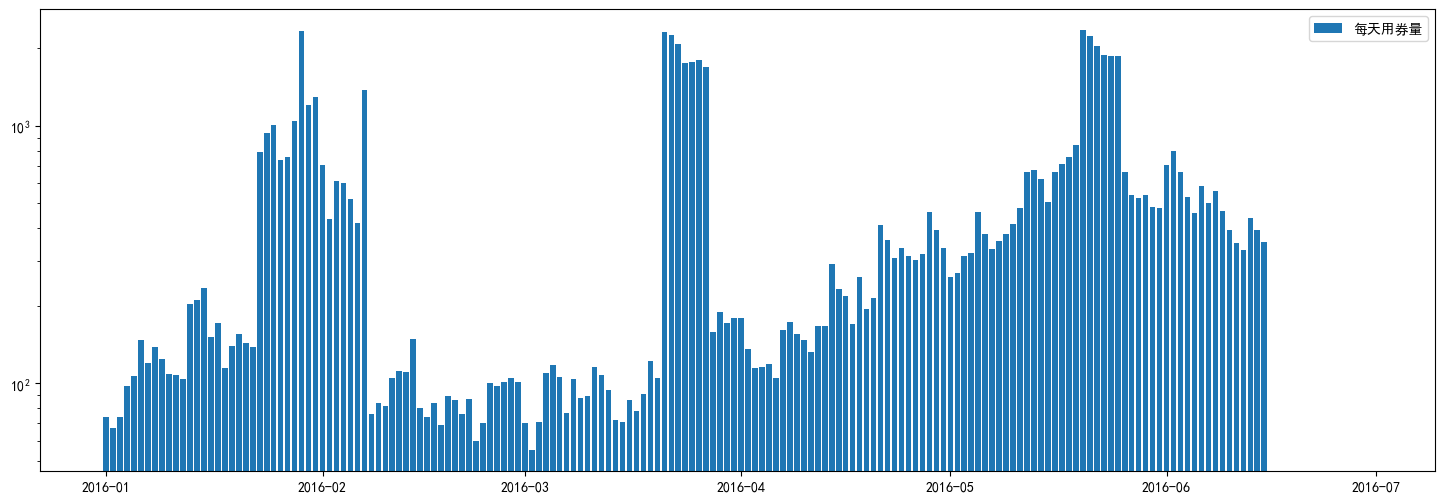

In [44]:
full_date = pd.DataFrame(index=date_sort)
consume_num_everday = full_date.join(consume_num_everday).fillna(0)

plt.figure(figsize=(18,6))
plt.bar(x=date_sort,height=consume_num_everday['count'],label='每天用券量')
plt.yscale('log')
plt.legend()

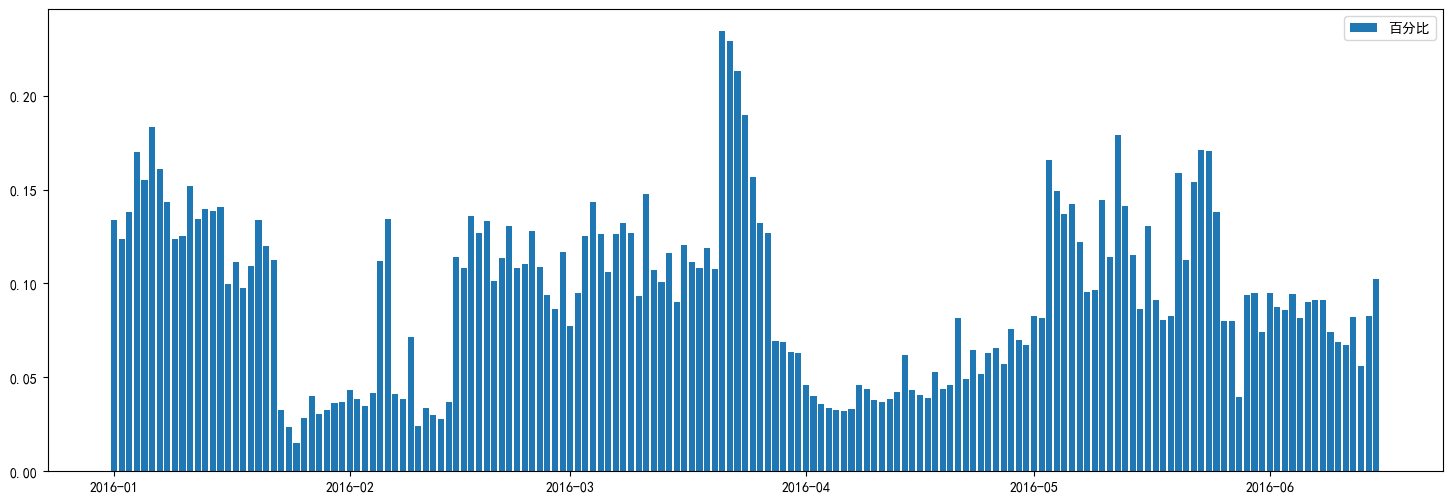

In [41]:
# 计算每天的优惠券使用量与发券量占比
plt.figure(figsize=(18,6))
plt.bar(x=date_received_sort,height=consume_num_everday['count']/coupon_sendout_everyday['count'],label='百分比')
plt.legend()

In [45]:
# 由图可知优惠券使用率最高在16年3月底，达到了30%
# 优惠券使用率波动较大